# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_34668\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

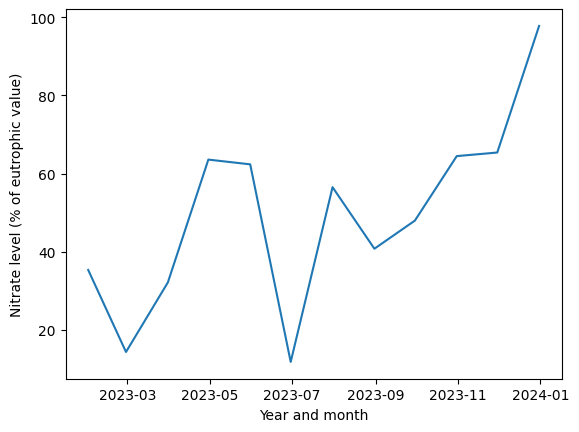

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_34668\1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

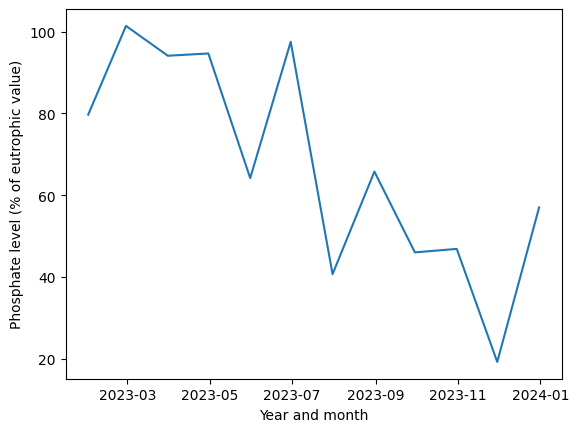

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

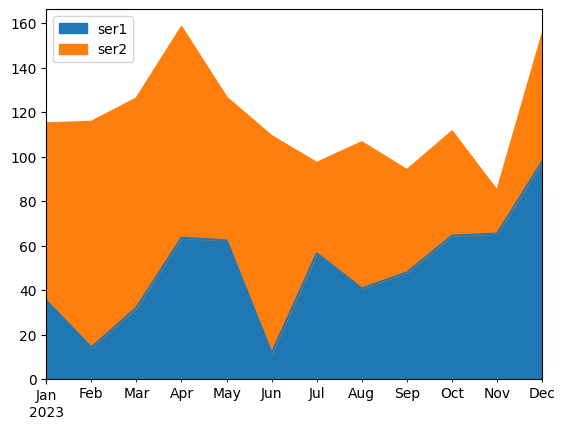

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

# 3. Working on your datasets — Bivariate Analysis

Bivariate analysis using the CMS Hospital Provider Cost Report (2018–2023).

In [6]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [7]:
files = {
    2018: 'Hospital_Provider_Cost_Report_2018.csv',
    2019: 'Hospital_Provider_Cost_Report_2019.csv',
    2020: 'Hospital_Provider_Cost_Report_2020.csv',
    2021: 'Hospital_Provider_Cost_Report_2021.csv',
    2022: 'Hospital_Provider_Cost_Report_2022.csv',
    2023: 'Hospital_Provider_Cost_Report_2023_updated.csv',
}

frames = []
for yr, f in files.items():
    df_tmp = pd.read_csv(f)
    df_tmp['report_year'] = yr
    frames.append(df_tmp)

df_all = pd.concat(frames, ignore_index=True)
df_all.to_csv('Hospital_Provider_Cost_Report_2018-2023.csv', index=True)

print(f"Combined shape: {df_all.shape}")
df_all.head()

Combined shape: (36560, 118)


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,report_year
0,639197,51994,FERN LODGE INC,18457 MADISON AVE,CASTRO VALLEY,CA,94546-1637,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,644158,341318,CHOWAN HOSPITAL INC.,211 VIRGINIA AVENUE,EDENTON,NC,27932,CHOWAN,99934.0,R,...,1211964.0,7117083.0,NaN,7117083.0,0.342405,7305948.0,17818589.0,38906.0,180387.0,2018
2,644255,102012,SPECIALTY HOSPITAL OF JACKSONVILLE,4901 RICHARD STREET,JACKSONVILLE,FL,32207,DUVAL,27260.0,U,...,35748.0,-1934317.0,-522.0,-1933795.0,NaN,NaN,NaN,NaN,NaN,2018
3,644287,221300,MARTHAS VINEYARD HOSPITAL,ONE HOSPITAL ROAD,OAK BLUFFS,MA,02557,DUKES,99922.0,R,...,5668549.0,59237.0,NaN,59237.0,0.504135,9736097.0,17034508.0,92090.0,174800.0,2018
4,644427,14014,BAYPOINT BEHAVIORAL HEALTH,5750 A SOUTHLAND DRIVE,MOBILE,AL,36693-3316,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018


In [8]:
def show_null_counts_features(df):
    
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)

    
    feature_types = df.dtypes.apply(
        lambda x: "Numeric" if np.issubdtype(x, np.number) else "Categorical"
    )

    
    missing_data = pd.DataFrame({
        "Feature": count_nulls[count_nulls > 0].index,
        "# Null Values": count_nulls[count_nulls > 0].values,
        "Null %": df_nulls[count_nulls > 0].values,          
        "Type": feature_types[count_nulls > 0].values
    }).sort_values(by="Null %", ascending=False)

    print(f"\nThe dataset contains {len(df):,} samples.\n")

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
        return

    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", None)

    
    missing_data = missing_data.reset_index(drop=True)
    missing_data["Null %"] = missing_data["Null %"].map(lambda x: f"{x:.2f}%")

    print(missing_data.to_string(index=False))


show_null_counts_features(df_all)



The dataset contains 36,560 samples.

                                                                Feature  # Null Values  Null %        Type
                                DRG Amounts Other Than Outlier Payments          36560 100.00%     Numeric
                          Hospital Total Days Title V For Adults & Peds          35668  97.56%     Numeric
                    Hospital Total Discharges Title V For Adults & Peds          35627  97.45%     Numeric
                                               Total Discharges Title V          35627  97.45%     Numeric
                                                     Total Days Title V          35578  97.31%     Numeric
                                                       Notes Receivable          35003  95.74%     Numeric
                                                        Unsecured Loans          34698  94.91%     Numeric
                                          Wage-Related Costs (RHC/FQHC)          34243  93.66%     Numeri

In [9]:
# Drop columns that are 100% null across all 6 years
empty_cols = df_all.columns[df_all.isna().mean() == 1.0]
df_clean = df_all.drop(columns=empty_cols)

print(f"Dropped {len(empty_cols)} fully-empty column(s): {empty_cols.tolist()}")
print(f"Remaining columns: {df_clean.shape[1]}")

# Classify columns
exclude_ids = ["rpt_rec_num", "Provider CCN", "Medicare CBSA Number"]
categorical_features = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = [
    c for c in df_clean.select_dtypes(include=["number"]).columns
    if c not in exclude_ids
]

print(f"\nNumeric features to impute: {len(numeric_features)}")
print(f"Categorical features to impute: {len(categorical_features)}")

Dropped 1 fully-empty column(s): ['DRG Amounts Other Than Outlier Payments']
Remaining columns: 117

Numeric features to impute: 104
Categorical features to impute: 10


In [10]:
# Impute numeric with median, categorical with most frequent
df_imputed = df_clean.copy()

num_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

# Drop rows where Medicare CBSA Number is still null
df_imputed = df_imputed.dropna(subset=["Medicare CBSA Number"]).copy()

print(f"Final cleaned dataset: {df_imputed.shape[0]:,} rows x {df_imputed.shape[1]} columns")
show_null_counts_features(df_imputed)

Final cleaned dataset: 36,096 rows x 117 columns

The dataset contains 36,096 samples.

There are no null values in the dataset!


In [11]:
# Map numeric control codes to ownership categories
control_map = {
    1.0: 'Voluntary Nonprofit', 2.0: 'Voluntary Nonprofit',
    3.0: 'Proprietary',         4.0: 'Proprietary',
    5.0: 'Proprietary',         6.0: 'Proprietary',
    7.0: 'Government',          8.0: 'Government',
    9.0: 'Government',          10.0: 'Government',
    11.0: 'Government',         12.0: 'Government',
    13.0: 'Government'
}
df_imputed['Control Type'] = df_imputed['Type of Control'].map(control_map)

# Map CCN facility type codes to readable labels
facility_map = {
    'STH':   'Short-Term Hospital',
    'CAH':   'Critical Access Hospital',
    'PH':    'Psychiatric Hospital',
    'RH':    'Rehabilitation Hospital',
    'LTCH':  'Long-Term Care Hospital',
    'CH':    'Childrens Hospital',
    'ORD':   'ORD Demonstration Hospital',
    'RNMHC': 'Religious Non-Medical Institution'
}
df_imputed['Facility Type Label'] = df_imputed['CCN Facility Type'].map(facility_map)

# Add COVID period flag for later bivariate analysis
df_imputed['COVID Period'] = df_imputed['report_year'].map({
    2018: 'Pre-COVID',
    2019: 'Pre-COVID',
    2020: 'COVID',
    2021: 'COVID',
    2022: 'Post-COVID',
    2023: 'Post-COVID'
})

print("Control Type distribution:")
print(df_imputed['Control Type'].value_counts())
print("\nFacility Type distribution:")
print(df_imputed['Facility Type Label'].value_counts())
print("\nCOVID Period distribution:")
print(df_imputed['COVID Period'].value_counts().reindex(['Pre-COVID','COVID','Post-COVID']))

Control Type distribution:
Control Type
Voluntary Nonprofit    18078
Proprietary            10687
Government              7331
Name: count, dtype: int64

Facility Type distribution:
Facility Type Label
Short-Term Hospital                  19671
Critical Access Hospital              8243
Psychiatric Hospital                  3540
Long-Term Care Hospital               2147
Rehabilitation Hospital               2002
Childrens Hospital                     383
Religious Non-Medical Institution       59
ORD Demonstration Hospital              51
Name: count, dtype: int64

COVID Period distribution:
COVID Period
Pre-COVID     12134
COVID         11960
Post-COVID    12002
Name: count, dtype: int64


In [12]:
# Net Income Margin = Net Income / Net Patient Revenue
df_imputed['Net Income Margin'] = (
    df_imputed['Net Income'] / df_imputed['Net Patient Revenue']
).replace([np.inf, -np.inf], np.nan)

print("Raw margin stats (before clipping):")
print(df_imputed['Net Income Margin'].describe())

df_imputed['Net Income Margin'] = df_imputed['Net Income Margin'].clip(-1.0, 1.0)

print("\nClipped margin stats:")
print(df_imputed['Net Income Margin'].describe())
print(f"\nNull margins remaining: {df_imputed['Net Income Margin'].isna().sum()}")

Raw margin stats (before clipping):
count    3.609600e+04
mean    -1.548081e+03
std      1.933996e+06
min     -1.589017e+08
25%     -3.574101e-02
50%      4.835535e-02
75%      1.378115e-01
max      2.959365e+08
Name: Net Income Margin, dtype: float64

Clipped margin stats:
count    36096.000000
mean         0.022536
std          0.255929
min         -1.000000
25%         -0.035741
50%          0.048355
75%          0.137812
max          1.000000
Name: Net Income Margin, dtype: float64

Null margins remaining: 0


In [13]:
total_cols_raw = df_all.shape[1]
dropped = df_all.columns[df_all.isna().mean() == 1.0]
high_missing = df_all.columns[
    (df_all.isna().mean() > 0.50) & (df_all.isna().mean() < 1.0)
]
low_missing = df_all.columns[
    (df_all.isna().mean() > 0) & (df_all.isna().mean() <= 0.50)
]

print(f"Total raw columns: {total_cols_raw}")
print(f"Dropped (100% null): {len(dropped)}")
print(f"High missingness >50%, imputed: {len(high_missing)}")
print(f"Low missingness 1-50%, imputed: {len(low_missing)}")
print(f"Complete columns (no nulls): {total_cols_raw - len(dropped) - len(high_missing) - len(low_missing)}")
print(f"\nFinal rows after cleaning: {df_imputed.shape[0]:,}")
print(f"Rows dropped (CBSA null): {len(df_clean) - len(df_imputed):,}")

Total raw columns: 118
Dropped (100% null): 1
High missingness >50%, imputed: 30
Low missingness 1-50%, imputed: 75
Complete columns (no nulls): 12

Final rows after cleaning: 36,096
Rows dropped (CBSA null): 464


Median Net Income Margin (%) by Year and Rural/Urban:
Rural Versus Urban  Rural  Urban
report_year                     
2018.0               1.95   4.56
2019.0               3.51   4.91
2020.0               9.18   8.05
2021.0               8.10   6.37
2022.0               1.57   2.37
2023.0               3.70   4.76


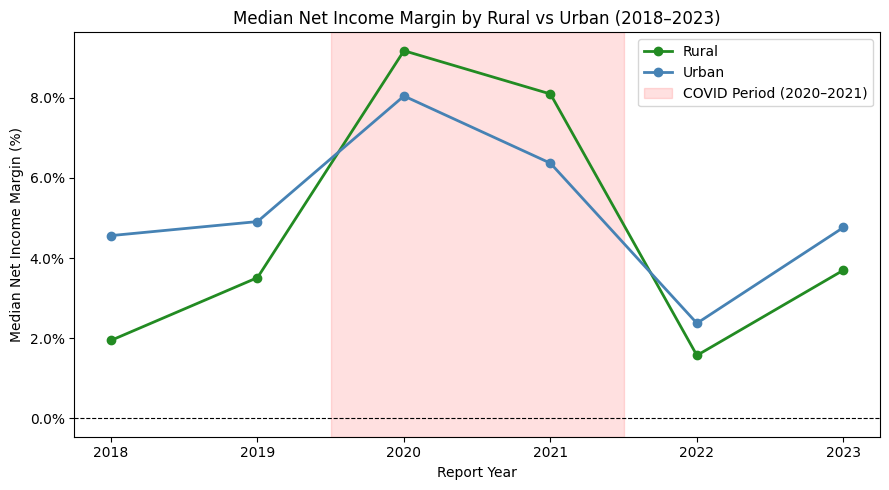

In [14]:
import matplotlib.ticker as mtick

margin_by_year_ru = (
    df_imputed
    .groupby(['report_year', 'Rural Versus Urban'])['Net Income Margin']
    .median()
    .unstack()
    .rename(columns={'R': 'Rural', 'U': 'Urban'})
) * 100

print("Median Net Income Margin (%) by Year and Rural/Urban:")
print(margin_by_year_ru.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(margin_by_year_ru.index, margin_by_year_ru['Rural'],
        marker='o', color='forestgreen', linewidth=2, label='Rural')
ax.plot(margin_by_year_ru.index, margin_by_year_ru['Urban'],
        marker='o', color='steelblue', linewidth=2, label='Urban')
ax.axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID Period (2020–2021)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Median Net Income Margin by Rural vs Urban (2018–2023)', fontsize=12)
ax.set_xlabel('Report Year')
ax.set_ylabel('Median Net Income Margin (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(margin_by_year_ru.index)
ax.legend()
plt.tight_layout()
plt.show()

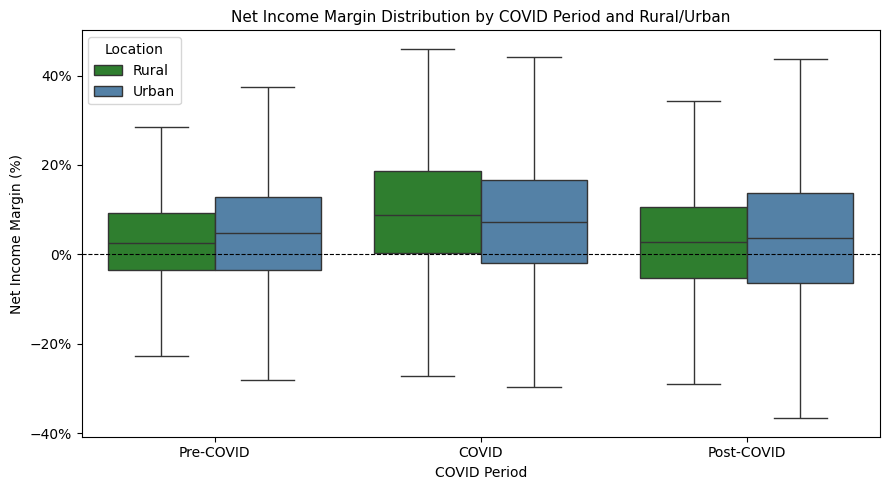

In [15]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))
period_order = ['Pre-COVID', 'COVID', 'Post-COVID']
ru_data = df_imputed[['COVID Period', 'Rural Versus Urban', 'Net Income Margin']].copy()
ru_data['Rural Versus Urban'] = ru_data['Rural Versus Urban'].map({'R': 'Rural', 'U': 'Urban'})
ru_data['Net Income Margin'] = ru_data['Net Income Margin'] * 100
ru_data['COVID Period'] = pd.Categorical(ru_data['COVID Period'], categories=period_order, ordered=True)

sns.boxplot(
    data=ru_data,
    x='COVID Period', y='Net Income Margin',
    hue='Rural Versus Urban',
    order=period_order,
    palette={'Rural': 'forestgreen', 'Urban': 'steelblue'},
    showfliers=False, ax=ax
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Net Income Margin Distribution by COVID Period and Rural/Urban', fontsize=11)
ax.set_xlabel('COVID Period')
ax.set_ylabel('Net Income Margin (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Location')
plt.tight_layout()
plt.show()

,Number of Beds,Net Income,Net Income Margin,Total Costs,Net Revenue from Medicaid,FTE - Employees on Payroll
Number of Beds,1.000,0.006,0.003,0.016,0.012,0.003
Net Income,0.006,1.000,0.340,0.334,0.186,0.048
Net Income Margin,0.003,0.340,1.000,0.052,0.033,-0.034
Total Costs,0.016,0.334,0.052,1.000,0.684,0.157
Net Revenue from Medicaid,0.012,0.186,0.033,0.684,1.000,0.109
FTE - Employees on Payroll,0.003,0.048,-0.034,0.157,0.109,1.000


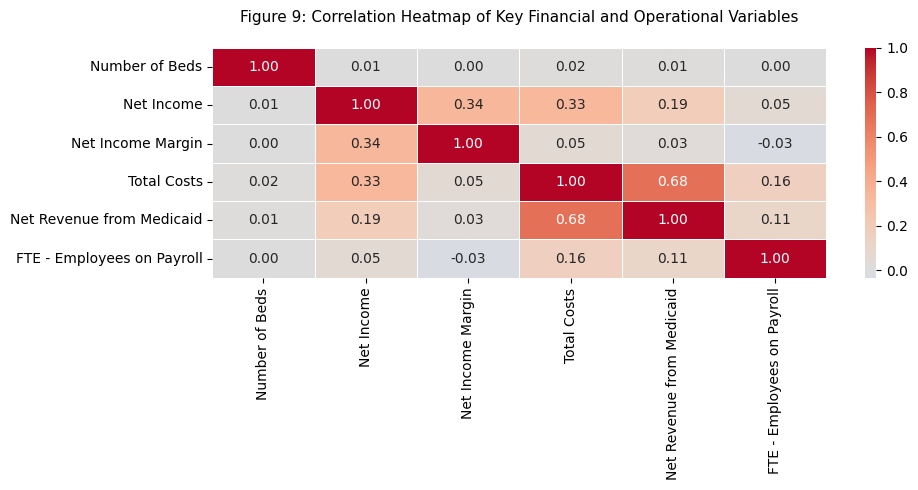

In [16]:
corr_cols = [
    'Number of Beds',
    'Net Income',
    'Net Income Margin',
    'Total Costs',
    'Net Revenue from Medicaid',
    'FTE - Employees on Payroll'
]


corr_table = df_imputed[corr_cols].corr().round(3)
display(corr_table)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    corr_table,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Figure 9: Correlation Heatmap of Key Financial and Operational Variables\n', fontsize=11)
plt.tight_layout()
plt.savefig('fig9_corr_heatmap.png', dpi=150)
plt.show()


## Conclusions

**Are the data what you expect?** Yes. Rural hospitals show lower median margins than urban hospitals pre-COVID, consistent with known structural funding gaps.

**Trend or pattern over time?** Both rural and urban margins surged during 2020–2021 before collapsing in 2022, indicating a temporary COVID-period improvement driven by external relief rather than structural change.

**Outliers?** The margin distribution has extreme values clipped to ±100% during preprocessing. Within that range, some hospitals still report margins at the floor or ceiling, visible as whisker endpoints in Figure 8.

**Highly correlated variables?** Total Costs and Net Revenue from Medicaid are correlated at 0.68, suggesting partial redundancy. Number of Beds is essentially uncorrelated with all financial outcomes (r ≈ 0.00–0.02).

**Usability?** The dataset is well-suited for the research question. 36,096 observations across six years with consistent annual participation and no significant structural gaps.